In [42]:
import pandas as pd
import numpy as np
import seaborn as sns

df=pd.read_csv('data/stud.csv')

In [5]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


prepare x and y variables



In [6]:
X=df.drop('math_score',axis=1)

In [7]:
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [8]:
y=df['math_score']

In [9]:
print("categories in [gender] variable:")
print(df['gender'].unique())
print("categories in [race_ethnicity] variable:")
print(df["race_ethnicity"].unique())
print("categories in [parental_level_of_education] variable:")
print(df["parental_level_of_education"].unique())
print("categories in [lunch] variable:")
print(df["lunch"].unique())
print("df['test_preparation_course'] variable:")
print(df['test_preparation_course'].unique())

categories in [gender] variable:
['female' 'male']
categories in [race_ethnicity] variable:
['group B' 'group C' 'group A' 'group D' 'group E']
categories in [parental_level_of_education] variable:
["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
categories in [lunch] variable:
['standard' 'free/reduced']
df['test_preparation_course'] variable:
['none' 'completed']


In [10]:
num_features=X.select_dtypes(exclude='object').columns
cat_features=X.select_dtypes(include='object').columns

from sklearn.preprocessing import OneHotEncoder ,StandardScaler
from sklearn.compose import ColumnTransformer

numeric_tranformer=StandardScaler()
oh_tranformer=OneHotEncoder()


In [11]:
preprocessor=ColumnTransformer(
    [
        ("standars_scalar",numeric_tranformer,num_features),
        ("OneHotEncoder",oh_tranformer,cat_features)
    ]
)

In [12]:
X=preprocessor.fit_transform(X)

In [16]:
X.shape

(1000, 19)

In [17]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((700, 19), (300, 19), (700,), (300,))

### create an evaluation function to give metrics to all the function ###

In [40]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [18]:
def evaluate_model(true,predicted):
    mae = mean_absolute_error(true,predicted)
    mse = mean_squared_error(true,predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(true,predicted)
    return mae, rmse, r2

In [37]:
from sklearn.neighbors import KNeighborsRegressor
import xgboost as XGB
XGBRegressor = XGB.XGBRegressor()

In [20]:
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor,GradientBoostingClassifier
models={
    "linear_regression": LinearRegression(),
    "ridge": Ridge(),
    "lasso": Lasso(),
    "decision_tree": DecisionTreeRegressor(),
    "K-nearest_neighbors": KNeighborsRegressor(),
    "random_forest": RandomForestRegressor(),
    "ada_boost": AdaBoostRegressor(),
    "XGBRegressor": XGBRegressor(),
    "gradient_boosting": GradientBoostingClassifier()
}

model_list=[]
r2_list=[]

for name, model in models.items():
    model.fit(X_train,y_train)
    y_train_pred=model.predict(X_train)
    y_pred=model.predict(X_test)
    mae_train, rmse_train, r2_train = evaluate_model(y_train,y_train_pred) 
    print(f"Model: {name}")
    print(f"MAE: {mae_train}")
    print(f"RMSE: {rmse_train}")
    print(f"R2 Score: {r2_train}") 

    mae, rmse, r2 = evaluate_model(y_test,y_pred)
    model_list.append(name)
    r2_list.append(r2)
    print("Test Set Evaluation:")
    print(f"MAE: {mae}")
    print(f"RMSE: {rmse}")
    print(f"R2 Score: {r2}")
    print("-"*30)

Model: linear_regression
MAE: 4.198519565142322
RMSE: 5.248303471123559
R2 Score: 0.8751313605993936
Test Set Evaluation:
MAE: 4.418261320297305
RMSE: 5.55757079919572
R2 Score: 0.8758630443016739
------------------------------
Model: ridge
MAE: 4.197676960902203
RMSE: 5.248655272909647
R2 Score: 0.8751146197676473
Test Set Evaluation:
MAE: 4.415505801902552
RMSE: 5.556591731362336
R2 Score: 0.875906778443454
------------------------------
Model: lasso
MAE: 5.158225799581063
RMSE: 6.510561578912617
R2 Score: 0.8078446842949261
Test Set Evaluation:
MAE: 5.39290266556218
RMSE: 6.87051433081567
R2 Score: 0.8102815436561874
------------------------------
Model: decision_tree
MAE: 0.02142857142857143
RMSE: 0.2988071523335984
R2 Score: 0.9995952401013053
Test Set Evaluation:
MAE: 6.493333333333333
RMSE: 8.188609975651138
R2 Score: 0.7305045390166442
------------------------------
Model: K-nearest_neighbors
MAE: 4.511714285714286
RMSE: 5.687806506654639
R2 Score: 0.8533422125782151
Test Set E

In [23]:
pd.DataFrame(list(zip(model_list,r2_list)),columns=['Model','R2 Score']).sort_values('R2 Score', ascending=False)

,Model,R2 Score
1,ridge,0.875907
0,linear_regression,0.875863
5,random_forest,0.848647
6,ada_boost,0.839952
7,XGBRegressor,0.811029
2,lasso,0.810282
4,K-nearest_neighbors,0.771733
3,decision_tree,0.730505
8,gradient_boosting,0.644857


## Linear rigression ##

In [38]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train,y_train)
y_pred=lin_model.predict(X_test)
score = r2_score(y_test,y_pred)*100
print(f"R2 Score: {score:.2f}%")


R2 Score: 87.59%


In [39]:
import matplotlib.pyplot as plt

### plot ypred and ytest

Text(0, 0.5, 'Predicted Values')

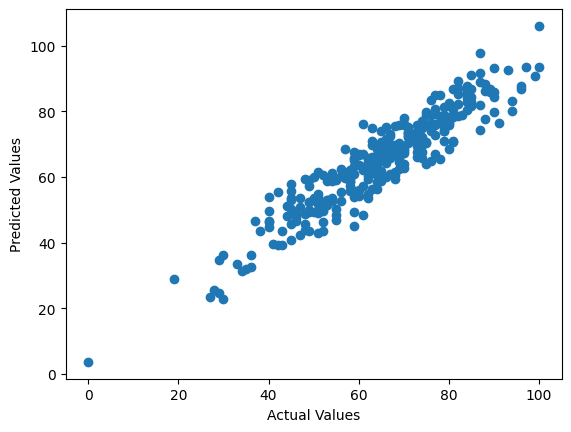

In [ ]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

<Axes: xlabel='math_score'>

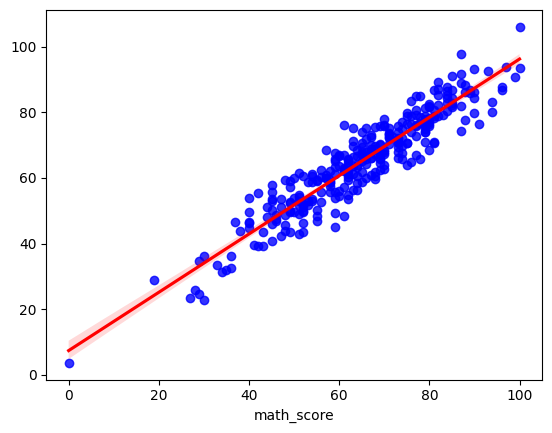

In [26]:
sns.regplot(x=y_test, y=y_pred, scatter_kws={"color": "blue"}, line_kws={"color": "red"})

#### difference between actual and predicted values ####


In [28]:
pred_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred, 'Difference': y_test - y_pred})

In [30]:
pred_df.head()

,Actual,Predicted,Difference
521,91,76.511652,14.488348
737,53,58.898180,-5.898180
740,80,76.938478,3.061522
660,74,76.965881,-2.965881
411,84,87.633152,-3.633152
